# 线性回归练习题

在这个练习中，我们使用一个Kaggle竞赛中提供的共享单车的数据集：[Bike Sharing Demand](https://www.kaggle.com/c/bike-sharing-demand/data)。
该数据集包含2011到2012年Capital Bikeshare系统中记录的每日每小时单车的租赁数，以及相应的季节和气候等信息。

数据列：
* **datetime** - hourly date + timestamp  
* **season** -  1 = spring, 2 = summer, 3 = fall, 4 = winter 
* **holiday** - whether the day is considered a holiday
* **workingday** - whether the day is neither a weekend nor holiday
* **weather** - 1: Clear, Few clouds, Partly cloudy, Partly cloudy；2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist；3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds；4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 
* **temp** - temperature in Celsius
* **atemp** - "feels like" temperature in Celsius
* **humidity** - relative humidity
* **windspeed** - wind speed
* **casual** - number of non-registered user rentals initiated
* **registered** - number of registered user rentals initiated
* **count** - number of total rentals

## 第一步：读入数据

In [2]:
# read the data and set the datetime as the index
import pandas as pd

bikes = pd.read_csv('bikeshare.csv', index_col='datetime', parse_dates=True)

In [2]:
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
datetime,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


## 第二步：可视化数据

* 用matplotlib画出温度“temp”和自行车租赁数“count”之间的散点图；
* 用seborn画出温度“temp”和自行车租赁数“count”之间带线性关系的散点图（提示：使用seaborn中的lmplot绘制）

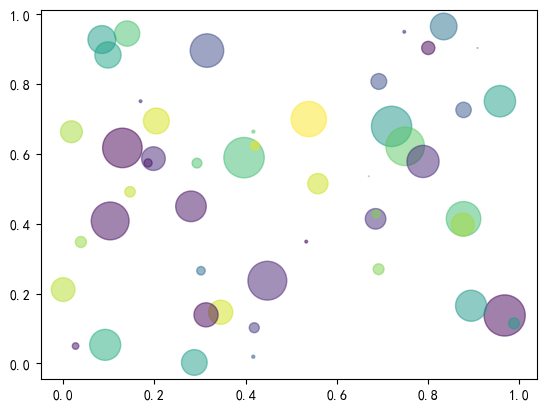

In [5]:
# matplotlib
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

N=50
x=np.random.rand(N)
y=np.random.rand(N)
colors=np.random.rand(N)
area=(30*np.random.rand(N))**2

plt.scatter(x,y,s=area,c=colors,alpha=0.5)
plt.show()

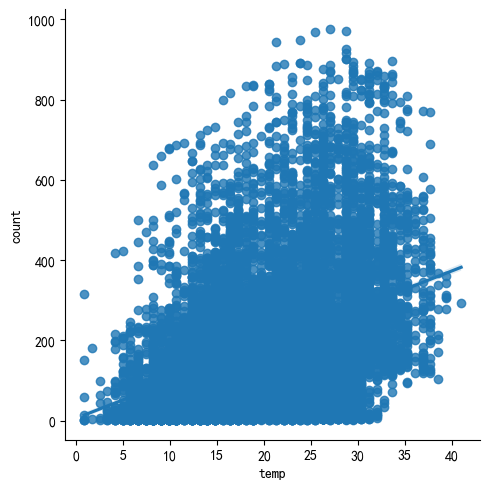

In [6]:
# seaborn
import seaborn as sns
sns.lmplot(x='temp', y='count', data=bikes)
plt.show()

## 第三步：一元线性回归

用温度预测自行车租赁数

In [7]:
# create X and y
X = bikes[['temp']]  # 特征（温度），注意用双括号确保是二维数组  
y = bikes['count']  

In [9]:
# import, instantiate, fit
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [10]:
# print the coefficients
print(f"回归系数（斜率）: {model.coef_[0]}")  
print(f"截距: {model.intercept_}")  

回归系数（斜率）: 9.170540481426201
截距: 6.046212959617549


## 第四步：探索多个特征

In [12]:
# explore more features
feature_cols = ['temp', 'season', 'weather', 'humidity']

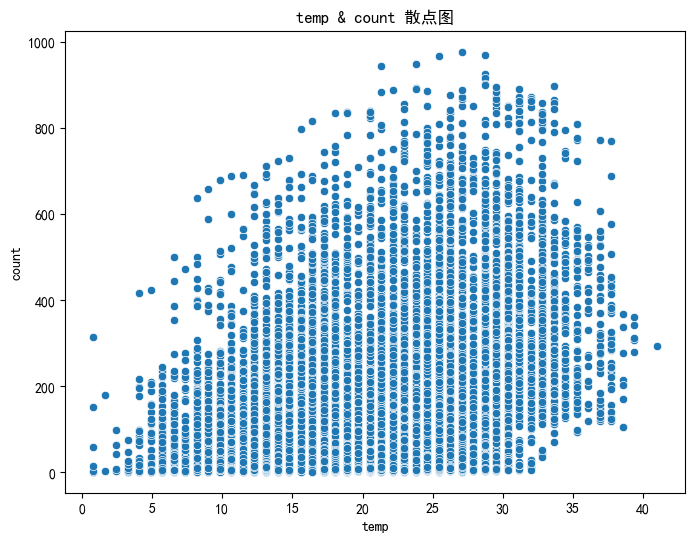

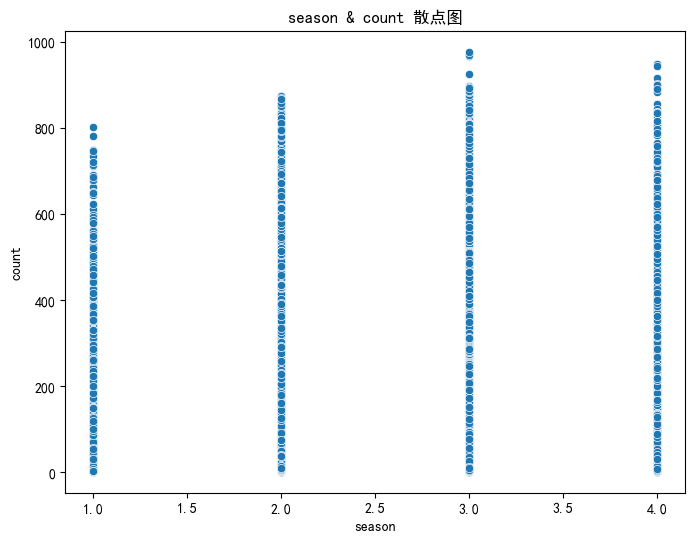

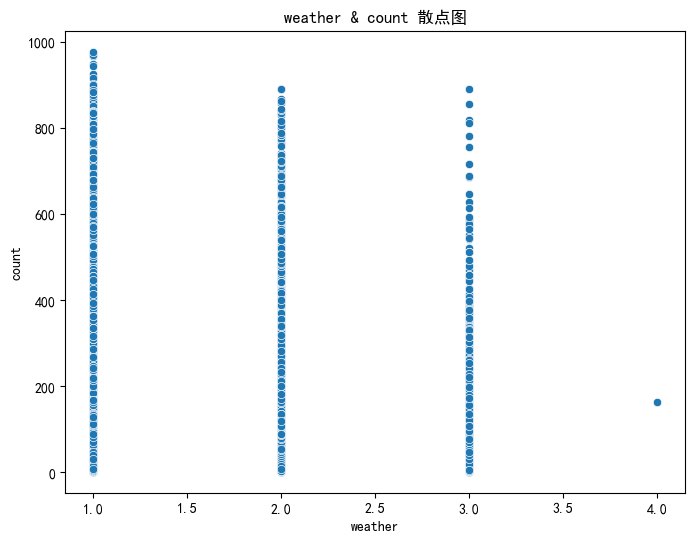

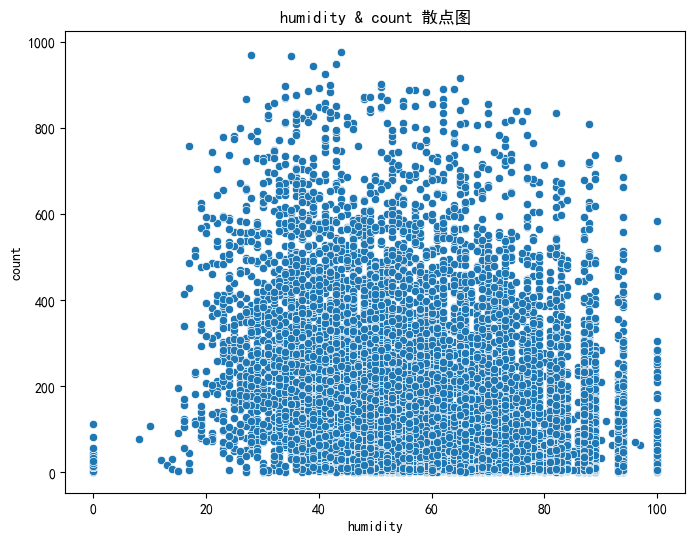

In [15]:
# using seaborn, draw multiple scatter plots between each feature in feature_cols and 'count'
for feature in feature_cols:  
    plt.figure(figsize=(8, 6))  # 设置图形大小  
    sns.scatterplot(x=feature, y='count', data=bikes)  
    plt.title(f"{feature} & count 散点图")  
    plt.xlabel(feature)  
    plt.ylabel('count')  
    plt.show()  

In [16]:
# correlation matrix (ranges from 1 to -1)
bikes.corr()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
season,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.096758,0.164011,0.163439
holiday,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,0.043799,-0.020956,-0.005393
workingday,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,-0.319111,0.119460,0.011594
weather,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.135918,-0.109340,-0.128655
temp,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454
atemp,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784
humidity,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371
windspeed,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369
casual,0.096758,0.043799,-0.319111,-0.135918,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414
registered,0.164011,-0.020956,0.119460,-0.109340,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948


<Axes: >

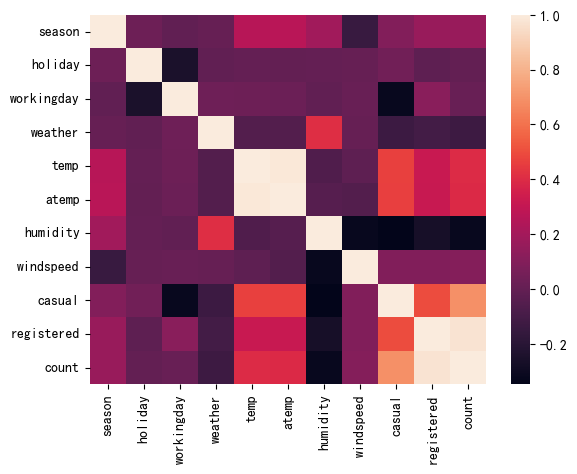

In [17]:
sns.heatmap(bikes.corr())

### 用'temp', 'season', 'weather', 'humidity'四个特征预测单车租赁数'count'

In [18]:
# create X and y
X = bikes[['temp', 'season', 'weather', 'humidity']]  
y = bikes['count']  

In [19]:
# import, instantiate, fit
from sklearn.linear_model import LinearRegression  
model = LinearRegression()  
model.fit(X, y) 

LinearRegression()

In [21]:
# print the coefficients
print("特征对应的系数:", model.coef_)  
print("模型截距:", model.intercept_)  

特征对应的系数: [ 7.86482499 22.53875753  6.67030204 -3.11887338]
模型截距: 159.52068786129803


### 使用train/test split和RMSE来比较多个不同的模型

In [28]:
# compare different sets of features
feature_cols1 = ['temp', 'season', 'weather', 'humidity']
feature_cols2 = ['temp', 'season', 'weather']
feature_cols3 = ['temp', 'season', 'humidity']
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
target_col = 'count'
# 定义一个函数来训练模型并计算 RMSE
def train_and_evaluate(X, y):
    # 划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 创建线性回归模型
    model = LinearRegression()

    # 训练模型
    model.fit(X_train, y_train)

    # 进行预测
    y_pred = model.predict(X_test)

    # 计算 RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return rmse
# 对每个特征组合进行训练和评估
for i, feature_cols in enumerate([feature_cols1, feature_cols2, feature_cols3], start=1):
    X = bikes[feature_cols]
    y = bikes[target_col]
    rmse = train_and_evaluate(X, y)
    print(f"feature_cols{i} 的 RMSE: {rmse}")

feature_cols1 的 RMSE: 154.88153824675462
feature_cols2 的 RMSE: 164.17140223751377
feature_cols3 的 RMSE: 154.96357288624588


## 补充：处理类别特征

有两种类别特征：

- **有序类别值：** 转换成相应的数字值(例如: small=1, medium=2, large=3)
- **无序类别值:** 使用dummy encoding (0/1编码)

此数据集中的类别特征有：

- **有序类别值：** weather (已经被编码成相应的数字值1,2,3,4)
- **无序类别值：** season (需要进行dummy encoding), holiday (已经被dummy encoded), workingday (已经被dummy encoded)

In [29]:
# create dummy variables
season_dummies = pd.get_dummies(bikes.season, prefix='season')

# print 5 random rows
season_dummies.sample(n=5, random_state=1)

,season_1,season_2,season_3,season_4
datetime,,,,
2011-09-05 11:00:00,False,False,True,False
2012-03-18 04:00:00,True,False,False,False
2012-10-14 17:00:00,False,False,False,True
2011-04-04 15:00:00,False,True,False,False
2012-12-11 02:00:00,False,False,False,True


In [ ]:
我们只需要 三个 dummy 变量 (不是四个)（删除第一列是为了消除多重共线性，
让模型的系数估计更加稳定，同时也能提高模型的解释性）, 
所以可以删除第一个dummy变量。

In [30]:
# drop the first column
season_dummies.drop(season_dummies.columns[0], axis=1, inplace=True)

# print 5 random rows
season_dummies.sample(n=5, random_state=1)

,season_2,season_3,season_4
datetime,,,
2011-09-05 11:00:00,False,True,False
2012-03-18 04:00:00,False,False,False
2012-10-14 17:00:00,False,False,True
2011-04-04 15:00:00,True,False,False
2012-12-11 02:00:00,False,False,True


In [31]:
# concatenate the original DataFrame and the dummy DataFrame (axis=0 means rows, axis=1 means columns)
bikes = pd.concat([bikes, season_dummies], axis=1)

# print 5 random rows
bikes.sample(n=5, random_state=1)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,season_2,season_3,season_4
datetime,,,,,,,,,,,,,,
2011-09-05 11:00:00,3,1,0,2,28.70,33.335,74,11.0014,101,207,308,False,True,False
2012-03-18 04:00:00,1,0,0,2,17.22,21.210,94,11.0014,6,8,14,False,False,False
2012-10-14 17:00:00,4,0,0,1,26.24,31.060,44,12.9980,193,346,539,False,False,True
2011-04-04 15:00:00,2,0,1,1,31.16,33.335,23,36.9974,47,96,143,True,False,False
2012-12-11 02:00:00,4,0,1,2,16.40,20.455,66,22.0028,0,1,1,False,False,True


### 将编码成的dummy变量加入回归模型的特征，预测单车租赁数

In [33]:
# include dummy variables for season in the model
feature_cols = ['temp', 'season_2', 'season_3', 'season_4', 'humidity']
X = bikes[feature_cols]  # 提取模型所需特征
y = bikes['count']       # 目标变量：单车租赁数

# 2. 划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

#训练线性回归模型
model = LinearRegression()
model.fit(X_train, y_train)  # 用训练集数据训练模型

# 预测并计算 RMSE（均方根误差）
y_pred = model.predict(X_test)  # 用测试集特征预测结果
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"含 season 虚拟变量的模型 RMSE: {rmse}")

含 season 虚拟变量的模型 RMSE: 153.70399462915924


和前面的模型进行比较